# First time testing a logistic regression model (classification)

In [2]:
#let's import the data directly from Kaggle
import kagglehub
from kagglehub import KaggleDatasetAdapter
from tqdm import tqdm

In [7]:
#Set the path to the file you'd like to load
#in our case it's one file, so no need to specify
file_path = "data.csv"

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "uciml/breast-cancer-wisconsin-data",
  file_path
)

display(df)
display(df.describe())
display(df.info())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

None

In [8]:
#last column "Unnamed" is empty, we can drop it
df = df.drop(columns=["Unnamed: 32"])

Target is "diagnosis". So we'd like to see if the tumor is M - malignant (1), or B - bening (0)

In [36]:
#Actually it seems that I could just download
#the dataset from sklearn. Let's try it

from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y=True)

# split train, test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(random_state=808, max_iter=10000).fit(X_train, y_train)

In [38]:
#let's look at the predictions for two random samples
for i in [8, 13]:  # add whatever indices you want
    print(f"Sample {i} → Prediction: {clf.predict([X[i, :]])[0]}, Probability: {clf.predict_proba([X[i, :]])[0][0]:.2f}")

Sample 8 → Prediction: 0, Probability: 0.94
Sample 13 → Prediction: 1, Probability: 0.34


In [17]:
#probabilities of predictions
clf.predict_proba([X[8, :]])


array([[0.94212242, 0.05787758]])

so 95% probability to be 0

0.5% to be 1

In [18]:
clf.predict_proba([X[13, :]])

array([[0.30746525, 0.69253475]])

the model is less certain in 2nd case

# Let's plot histogramme of prediction probabilities.

It's a good way to analyse the performance of the model

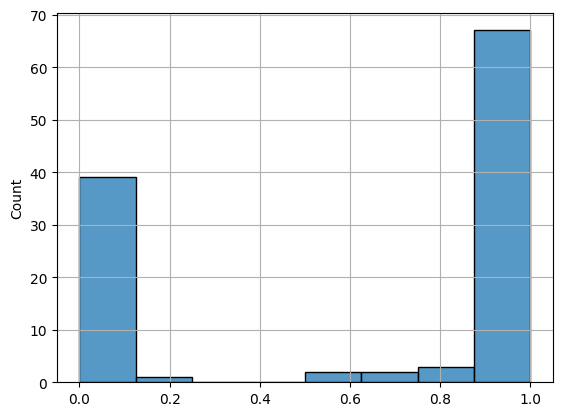

In [50]:
y_hat_proba = clf.predict_proba(X_test)[:,1]
import seaborn as sns
ax = sns.histplot(y_hat_proba)
ax.grid(True)

Since most of predictions are close to 0 or 1, the model is trustworthy

# Best metric to evaluate performance of a classification model is accuracy (l'exactitude)

Accuracy = correct predictions / total predictions

In [40]:
y_pred = clf.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.956140350877193

95% is a very good score for a simple logistic regression model

# Is it biased (has a tendancy to put 0 to 1 and 1 to 0)?

Confusion matrix would show it

In [41]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[39,  4],
       [ 1, 70]])

39 True Negatives  4 False Positives

1 False Negatives   70 True Positives

# Let's test performances with different limits (by default it's 0.5)

In [45]:
y_hat_proba = clf.predict_proba(X_test)[:,1]

y_pred_03 = [ 0 if value < 0.3 else 1 for value in y_hat_proba ]
y_pred_07 = [ 0 if value < 0.7 else 1 for value in y_hat_proba ]

display(confusion_matrix(y_test, y_pred_03))
confusion_matrix(y_test, y_pred_07)

array([[39,  4],
       [ 1, 70]])

array([[41,  2],
       [ 1, 70]])

In [47]:
from sklearn.metrics import precision_score, recall_score
import pandas as pd
results = pd.DataFrame({
    'y_pred_03': [accuracy_score(y_test, y_pred_03), precision_score(y_test, y_pred_03), recall_score(y_test, y_pred_03)],
    'y_pred':    [accuracy_score(y_test, y_pred),    precision_score(y_test, y_pred),    recall_score(y_test, y_pred)],
    'y_pred_07': [accuracy_score(y_test, y_pred_07), precision_score(y_test, y_pred_07), recall_score(y_test, y_pred_07)],
}, index=['Accuracy', 'Precision', 'Recall'])

display(results.round(3))


,y_pred_03,y_pred,y_pred_07
Accuracy,0.956,0.956,0.974
Precision,0.946,0.946,0.972
Recall,0.986,0.986,0.986


Very good results

# Now let's look at ROC AUC

The graph is Receiving operating characteristic (ROC)

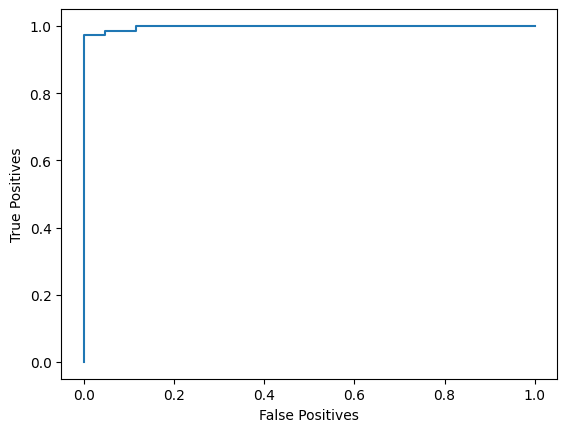

In [48]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_hat_proba)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr)
plt.xlabel('False Positives')
plt.ylabel('True Positives')
plt.show()

The more square it is the better, so in our case it's almost perfect

Classification report

In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

